/home/sjy990426/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.14.0         Please see GitHub issue #2919 for more info


[Embedder] 'sentence-transformers/all-MiniLM-L6-v2' on cuda


Batches: 100%|██████████| 1141/1141 [00:25<00:00, 45.20it/s]


[Partition] offline=2920 (seed=110, rand=2810) online=26277
[Tie] strict_ratio(tie==1)=0.9975 tie_mean=1.002 tie_max=2
[B-Pretrain] using OFFLINE full (top1)
[Offline] SupCon(B) tr=2628 val=292 bs=512 epochs=10000 pos=top1
[ep=    1] batch=6.2158 tr_eval=6.2518 val_eval=5.6848 density=0.123 row_pos=(63.0, 63.0, 63.0) top_w=[(0, 64), (1, 64), (2, 64), (3, 64), (4, 64)]
[ep=   50] batch=6.0516 tr_eval=6.2738 val_eval=5.7417 density=0.123 row_pos=(63.0, 63.0, 63.0) top_w=[(0, 64), (1, 64), (5, 64), (6, 64), (7, 64)]
[ep=  100] batch=5.6980 tr_eval=6.2029 val_eval=5.8284 density=0.123 row_pos=(63.0, 63.0, 63.0) top_w=[(0, 64), (1, 64), (2, 64), (4, 64), (5, 64)]
[ep=  150] batch=5.6587 tr_eval=6.0681 val_eval=5.8000 density=0.123 row_pos=(63.0, 63.0, 63.0) top_w=[(0, 64), (1, 64), (2, 64), (4, 64), (5, 64)]
[ep=  200] batch=5.3834 tr_eval=6.0921 val_eval=5.8484 density=0.123 row_pos=(63.0, 63.0, 63.0) top_w=[(0, 64), (2, 64), (3, 64), (4, 64), (5, 64)]
[ep=  250] batch=5.6680 tr_eval=5.996

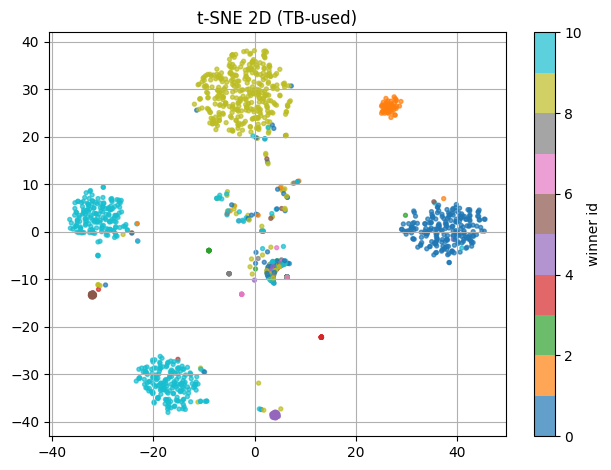

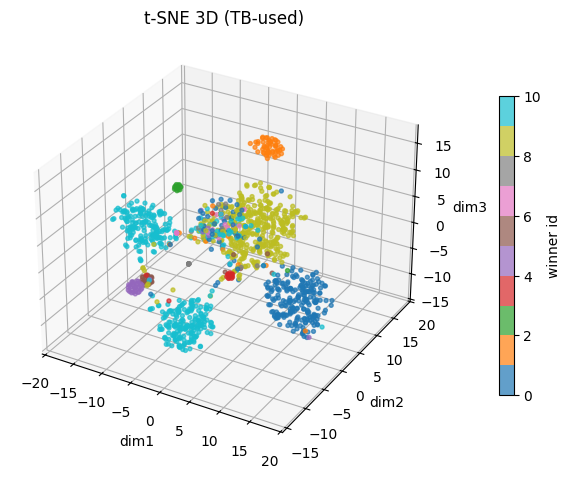

[Probe][TB-used] {'knn_acc': 0.7796803652968036, 'linear_acc': 0.7636986301369864}
[Probe][Test] {'knn_acc': 0.29777777777777775, 'linear_acc': 0.3333333333333333}


In [1]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

from queue_config import QueueConfig
from mnl_router import MNLRouter

from train import (
    compute_acc_cost_util_all,
    Embedder,
    build_offline_partition_strict_only_per_model,
    build_offline_partition_mincover_then_random,
)
from train_by_model.routerbench_train import load_routerbench_pkl as load_routerbench

from b_diagnostics import (
    offline_pretrain_B_supcon_with_val,
    collapse_report, plot_pca, plot_tsne, plot_cos_hist, plot_singular_values,
    probe_separability, plot_pca_3d, plot_tsne_3d,
)

DATA_PATH = "/home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/routerbench_0shot.pkl"

# -------------------------
# Config
# -------------------------
cfg = QueueConfig()
device = torch.device(cfg.device)

import random, numpy as np, torch
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(int(cfg.seed))

btype = str(getattr(cfg, "b_type", "none")).lower().strip()

# -------------------------
# Load data -> acc/util
# -------------------------
df, models, cost_map = load_routerbench(DATA_PATH, use_cost=bool(cfg.use_cost))
acc_all, util_all = compute_acc_cost_util_all(
    df, models, cost_map,
    use_cost=bool(cfg.use_cost),
    lam_cost=float(cfg.lam_cost),
)

# -------------------------
# Prompt -> embedding
# -------------------------
texts = df["prompt"].astype(str).tolist()
embedder = Embedder(cfg.embedder_model, device=device)
X_all = embedder.transform(texts)  # (N, d_ctx)
d_ctx = int(X_all.shape[1])
K_models = int(len(models))

# -------------------------
# Train/Test split
# -------------------------
idx_all = np.arange(len(df), dtype=np.int64)
idx_tr, idx_te = train_test_split(
    idx_all,
    test_size=float(cfg.test_size),
    random_state=int(cfg.seed),
    shuffle=True,
)

X_train, U_train = X_all[idx_tr], util_all[idx_tr]
X_test,  U_test  = X_all[idx_te], util_all[idx_te]

# -------------------------
# Offline split inside Train (strict-only 정책 적용)
# -------------------------
if btype == "none":
    seed_idx, rand_idx, offline_idx, online_idx = build_offline_partition_strict_only_per_model(
        util_train=U_train,
        n_per_model=int(getattr(cfg, "offline_seed_min_per_model", 10)),
        tie_eps=float(getattr(cfg, "offline_tie_eps", 1e-9)),
        seed=int(cfg.seed) + 999,
    )
else:
    seed_idx, rand_idx, offline_idx, online_idx = build_offline_partition_mincover_then_random(
        util_train=U_train,
        offline_total_ratio=float(getattr(cfg, "offline_total_ratio", 0.2)),
        min_per_model=int(getattr(cfg, "offline_seed_min_per_model", 10)),
        tie_eps=float(getattr(cfg, "offline_tie_eps", 1e-9)),
        seed=int(cfg.seed),
    )

X_off = X_train[offline_idx]
U_off = U_train[offline_idx]

X_seed = X_train[seed_idx]
U_seed = U_train[seed_idx]

print(f"[Partition] offline={len(offline_idx)} (seed={len(seed_idx)}, rand={len(rand_idx)}) online={len(online_idx)}")

# tie 통계 확인
mx = U_train.max(axis=1, keepdims=True)
co_first = U_train >= (mx - float(getattr(cfg, "offline_tie_eps", 1e-9)))
tie_size = co_first.sum(axis=1)
print(f"[Tie] strict_ratio(tie==1)={float((tie_size==1).mean()):.4f} tie_mean={float(tie_size.mean()):.3f} tie_max={int(tie_size.max())}")

# -------------------------
# Choose pool for B pretrain diagnostics
# - 네 정책: pos_strategy와 무관하게 OFFLINE full 사용
# -------------------------
pos_strategy = str(getattr(cfg, "supcon_pos_strategy", "top1")).lower().strip()
if btype == "none":
    raise RuntimeError("b_type=none이면 B pretrain 진단을 돌릴 게 없다. b_type을 linear/mlp로 바꿔야 한다.")
else:
    X_tb, U_tb = X_off, U_off
    print(f"[B-Pretrain] using OFFLINE full ({pos_strategy})")

# -------------------------
# TB train/val split
# -------------------------
tb_idx = np.arange(len(X_tb), dtype=np.int64)
tb_tr, tb_va = train_test_split(
    tb_idx,
    test_size=0.1,
    random_state=int(cfg.seed),
    shuffle=True,
)

X_tb_tr, U_tb_tr = X_tb[tb_tr], U_tb[tb_tr]
X_tb_va, U_tb_va = X_tb[tb_va], U_tb[tb_va]

# -------------------------
# Router init (B only pretrain)
# -------------------------
d_proj_eff = int(cfg.d_proj if btype != "none" else d_ctx)

router = MNLRouter(
    d_ctx=int(d_ctx),
    n_models=int(K_models),
    d_proj=d_proj_eff,
    combine_mode = cfg.combine_mode,
    lambda_0=float(cfg.lambda_0),
    supcon_temp=float(cfg.supcon_temp),
    device=str(cfg.device),
    b_type=str(cfg.b_type),
    b_hidden_mult=int(cfg.b_hidden_mult),
    lr_b=float(cfg.offline_lr_B),
).to(device)

# -------------------------
# Offline B pretrain + diagnostics
# -------------------------
offline_pretrain_B_supcon_with_val(
    router=router,
    X_tr=X_tb_tr, U_tr=U_tb_tr,
    X_va=X_tb_va, U_va=U_tb_va,
    cfg=cfg,
    n_models=K_models,
    log_every=50,
    pos_density_warn=0.25,
)

# -------------------------
# Collapse / plots / probes
# -------------------------
rep_tb, Z_tb, y_tb = collapse_report(router, X_tb, U_tb, n_vis=3000, max_pairs=200_000, seed=0)
print("[Collapse][TB-used]", rep_tb)

rep_te, Z_te, y_te = collapse_report(router, X_test, U_test, n_vis=3000, max_pairs=200_000, seed=1)
print("[Collapse][Test]", rep_te)

plot_tsne(Z_tb, y_tb, "t-SNE 2D (TB-used)", tsne_n=1500, perplexity=30)
plot_tsne_3d(Z_tb, y_tb, "t-SNE 3D (TB-used)", seed=0, tsne_n=1500, perplexity=30)

if y_tb is not None:
    print("[Probe][TB-used]", probe_separability(Z_tb, y_tb, seed=0))
if y_te is not None:
    print("[Probe][Test]", probe_separability(Z_te, y_te, seed=0))


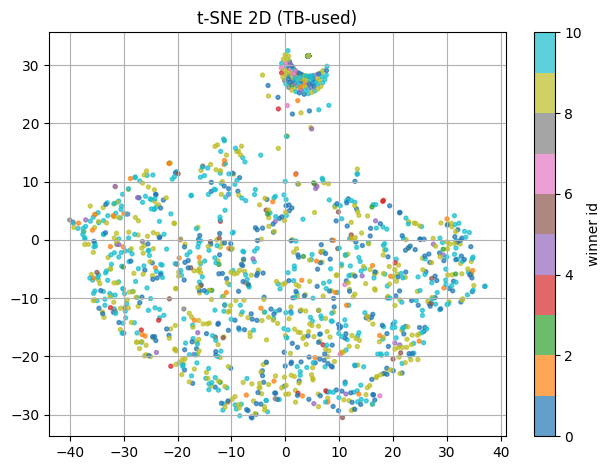

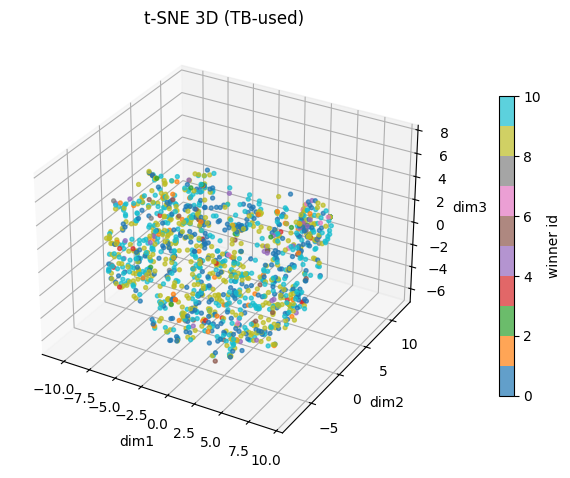

In [2]:
plot_tsne(Z_te, y_te, "t-SNE 2D (TB-used)", tsne_n=1500, perplexity=30)
plot_tsne_3d(Z_te, y_te, "t-SNE 3D (TB-used)", seed=0, tsne_n=1500, perplexity=30)
